# Interference Sweep

> Sweep a single parameter to examine its effect on film recall in the selective interference paradigm.

The selective interference paradigm encodes film items, then break items (modeling a retention interval), a reminder that reinstates film context, interference items, and filler items before free recall.
This notebook sweeps one parameter at a time — either a scale factor that modulates encoding/retrieval rates, or the number of items in a phase — and produces a two-panel figure: serial position curves (left) and mean film items recalled with 95% CI (right).
Override the parameters cell via papermill to target different sweeps.


In [1]:
import csv
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown
from jax import random

from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root
from selective_interference_v2 import (
    Paradigm,
    add_filler_boundary,
    compute_n_presented,
    film_recalled_stats,
    light_to_dark_colors,
    load_fit_params,
    make_factory,
    make_is_emotional,
    plot_interference_spc,
    plot_summary_dv,
    prepare_sweep,
    run_count_sweep,
    run_sweep,
    save_figure,
    split_scales_for_cache,
    standard_remap,
    break_extended_remap,
    interference_extended_remap,
    filler_extended_remap,
)

warnings.filterwarnings("ignore")


In [2]:
# --- sweep configuration ---
SWEEP_TITLE = "SPC by Interference MCF Scale"
SWEEP_MODE = "scale"          # "scale" or "count"
SWEEP_PARAM = "interference_mcf_scale"
SWEEP_VALUES = [0.0, 0.33, 0.67, 1.0, 1.33, 1.67, 2.0, 2.33, 2.67, 3.0]
SWEEP_XLABEL = "Interference MCF Scale"
SWEEP_LABEL_FMT = "{:.2f}"
SWEEP_MOTIVATION = ""

# --- paradigm geometry ---
N_FILM = 16
N_BREAK = 0
N_INTERFERENCE = 16
N_FILLER = 16
N_BREAK_MAX = 32
N_INTERFERENCE_MAX = 32
N_FILLER_MAX = 32
EXPERIMENT_COUNT = 5000
SHOW_BREAK_IN_SPC = False
SHOW_FILLERS_IN_SPC = True

# --- emotional mechanism ---
FILM_EMOTIONAL = False
INTERFERENCE_EMOTIONAL = False

# --- cache strategy ---
# For scale sweeps only (count sweeps derive this automatically).
# The model is encoded through the chosen phase boundary before
# the sweep begins; phases after the boundary are re-run per
# sweep value.  Set this to the latest phase whose parameters
# are NOT being swept:
#   "creation"      — for sweeping film-phase or encoding params
#   "film"          — for sweeping break params (break_drift_scale,
#                     break_mcf_scale)
#   "break"         — for sweeping reminder params (reminder_drift_scale,
#                     reminder_start_drift_scale)
#   "reminder"      — default; sweeps interference/filler/retrieval params
#   "interference"  — for sweeping filler params only
#   "filler"        — all phases pre-cached; only retrieval varies
CACHE_AFTER = "reminder"

# --- fixed scale factors (held constant across sweep values) ---
FIXED_SCALES = {
    "break_drift_scale": 1.0,
    "break_mcf_scale": 1.0,
    "reminder_start_drift_scale": 0.0,
    "reminder_drift_scale": 0.0,
    "filler_drift_scale": 1.0,
    "filler_mcf_scale": 1.0,
}

# --- parameter loading ---
SEED = 0
DATA_TAG = "Dupertuys2026"
MODEL_NAME = "eCMR_source_only_phi"
RUN_TAG = "learn_after_encoding_free_recall_1_diffw_0p5_1p0_rtol_1e-4_pooled_evosax_positional_term_best_of_1"
FIT_DIR = "results/fits"
FIT_PATH = ""  # optional explicit path; blank derives DATA_TAG_MODEL_NAME_RUN_TAG.json
FIGURE_DIR = ""
FIGURE_STR = ""


In [3]:
# Parameters
SWEEP_VALUES = [0.01, 0.33, 0.67, 1.0, 1.33, 1.67, 2.0, 2.33, 2.67, 3.0]
N_BREAK = 16
SHOW_BREAK_IN_SPC = True
FIGURE_DIR = "figures"
FIGURE_STR = "interference_mcf_scale_delay16_comp_ss0_positive_no_reminder"
SWEEP_TITLE = "SPC by Interference MCF Scale (Delay, No Reminder, Competitor SS 0)"
FIXED_SCALES = {"break_drift_scale": 1.0, "break_mcf_scale": 1.0, "reminder_start_drift_scale": 0.0, "reminder_drift_scale": 0.0, "filler_drift_scale": 1.0, "filler_mcf_scale": 1.0, "competitor_shared_support_scale": 0.0}


In [4]:
#| output: asis
if SWEEP_MOTIVATION:
    display(Markdown(SWEEP_MOTIVATION))

In [5]:
# --- derive tier and cache_after for count sweeps ---
_COUNT_TIER = {
    "n_break": "break_extended",
    "n_interference": "interference_extended",
    "n_filler": "filler_extended",
}
_COUNT_CACHE = {
    "n_break": "film",
    "n_interference": "reminder",
    "n_filler": "reminder",
}
if SWEEP_MODE == "count":
    _tier = _COUNT_TIER[SWEEP_PARAM]
    _cache_after = _COUNT_CACHE[SWEEP_PARAM]
else:
    _tier = "standard"
    _cache_after = CACHE_AFTER

paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    n_break_max=N_BREAK_MAX,
    n_interference_max=N_INTERFERENCE_MAX,
    n_filler_max=N_FILLER_MAX,
    experiment_count=EXPERIMENT_COUNT,
)

project_root = Path(find_project_root())
if FIT_PATH:
    fit_path = project_root / FIT_PATH
else:
    fit_dir = project_root / FIT_DIR
    fit_path = fit_dir / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

figure_dir = str(project_root / FIGURE_DIR) if FIGURE_DIR else ""

is_emotional = make_is_emotional(paradigm, FILM_EMOTIONAL, INTERFERENCE_EMOTIONAL)
factory = make_factory(is_emotional=is_emotional)
rng = random.PRNGKey(SEED)

params, n_subjects = load_fit_params(fit_path)

pre_cache_scales, post_cache_scales = split_scales_for_cache(
    FIXED_SCALES,
    _cache_after,
)

prep = prepare_sweep(
    params, paradigm, factory,
    cache_after=_cache_after, tier=_tier,
    **pre_cache_scales,
)
print(f"{n_subjects} subjects, tier={_tier}, cache_after={_cache_after}")
print(f"pre-cache scales: {pre_cache_scales}")
print(f"post-cache scales: {post_cache_scales}")

1 subjects, tier=standard, cache_after=reminder
pre-cache scales: {'break_drift_scale': 1.0, 'break_mcf_scale': 1.0, 'reminder_start_drift_scale': 0.0, 'reminder_drift_scale': 0.0, 'competitor_shared_support_scale': 0.0}
post-cache scales: {'filler_drift_scale': 1.0, 'filler_mcf_scale': 1.0}


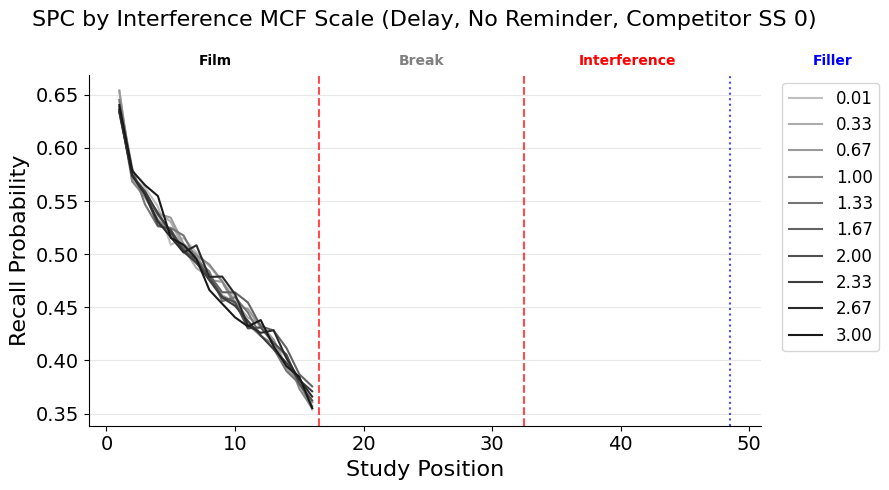

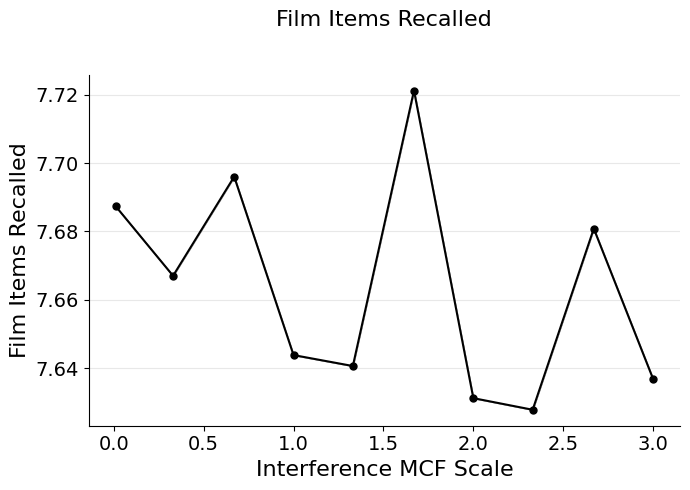

In [6]:
sweep_values = np.array(SWEEP_VALUES)

# --- run sweep ---
if SWEEP_MODE == "scale":
    recalls_4d, rng = run_sweep(
        prep, rng, **{**post_cache_scales, SWEEP_PARAM: sweep_values},
    )
else:
    recalls_4d, rng = run_count_sweep(
        prep, rng, paradigm, SWEEP_PARAM, [int(v) for v in sweep_values],
        **post_cache_scales,
    )

# --- remap + SPC + stats ---
_remap_fn = {
    "standard": standard_remap,
    "break_extended": break_extended_remap,
    "interference_extended": interference_extended_remap,
    "filler_extended": filler_extended_remap,
}[_tier]

_remap_kw = {}
if _tier == "break_extended":
    _remap_kw["n_break"] = paradigm.n_break_max
elif _tier == "interference_extended":
    _remap_kw["n_interference"] = paradigm.n_interference_max

# For count sweeps the remap always uses max slots, so compute SPC
# and plot mask at the max n_presented.  Unused positions show as
# NaN via the arr[arr == 0.0] = np.nan guard in plot_interference_spc.
if SWEEP_MODE == "count":
    _max_kw = {SWEEP_PARAM: int(max(sweep_values))}
    if _tier == "break_extended":
        _max_kw["n_break"] = paradigm.n_break_max
    elif _tier == "interference_extended":
        _max_kw["n_interference"] = paradigm.n_interference_max
    elif _tier == "filler_extended":
        _max_kw["n_filler"] = paradigm.n_filler_max
    n_presented = compute_n_presented(
        paradigm,
        show_break=SHOW_BREAK_IN_SPC,
        show_fillers=SHOW_FILLERS_IN_SPC,
        **_max_kw,
    )
else:
    n_presented = compute_n_presented(
        paradigm,
        show_break=SHOW_BREAK_IN_SPC,
        show_fillers=SHOW_FILLERS_IN_SPC,
    )

spcs, stats = [], []
for i in range(recalls_4d.shape[0]):
    recalls = recalls_4d[i].reshape(-1, recalls_4d.shape[-1])
    recalls = _remap_fn(recalls, paradigm, **_remap_kw)
    spcs.append(fixed_pres_spc(recalls, n_presented))
    stats.append(film_recalled_stats(recalls, paradigm, n_subjects))

# --- summary stats ---
# Effective zone widths for boundary placement (match remap output)
_n_break_plot = paradigm.n_break_max if _tier == "break_extended" else N_BREAK
_n_interf_plot = paradigm.n_interference_max if _tier == "interference_extended" else N_INTERFERENCE
_n_filler_plot = paradigm.n_filler_max if _tier == "filler_extended" else N_FILLER

n_break_shown = _n_break_plot if SHOW_BREAK_IN_SPC else 0
if SWEEP_MODE == "scale" and SWEEP_PARAM == "reminder_start_drift_scale":
    _reminder_start_values = sweep_values
else:
    _reminder_start_values = np.array([
        FIXED_SCALES.get("reminder_start_drift_scale", 1.0)
    ])
if SWEEP_MODE == "scale" and SWEEP_PARAM == "reminder_drift_scale":
    _reminder_values = sweep_values
else:
    _reminder_values = np.array([
        FIXED_SCALES.get("reminder_drift_scale", 1.0)
    ])
reminder_label = (
    "Reminder"
    if np.any(_reminder_start_values != 0.0) or np.any(_reminder_values != 0.0)
    else None
)
labels = [SWEEP_LABEL_FMT.format(v) for v in sweep_values]
colors = light_to_dark_colors(len(spcs))
means, ci_lo, ci_hi = zip(*stats)

if figure_dir and FIGURE_STR:
    os.makedirs(figure_dir, exist_ok=True)
    csv_path = os.path.join(figure_dir, f"{FIGURE_STR}.csv")
    with open(csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["value", "mean", "ci_lower", "ci_upper"])
        for v, m, lo, hi in zip(sweep_values, means, ci_lo, ci_hi):
            writer.writerow([v, m, lo, hi])

    # SPC sidecar
    spc_csv_path = os.path.join(figure_dir, f"{FIGURE_STR}_spc.csv")
    with open(spc_csv_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["value", "position", "phase", "recall_prob"])
        for val, spc in zip(sweep_values, spcs):
            arr = np.asarray(spc, dtype=float)
            for pos_idx in range(len(arr)):
                pos = pos_idx + 1
                if pos <= N_FILM:
                    phase = "film"
                elif pos <= N_FILM + n_break_shown:
                    phase = "break"
                elif pos <= N_FILM + n_break_shown + _n_interf_plot:
                    phase = "interference"
                else:
                    phase = "filler"
                writer.writerow([val, pos, phase, arr[pos_idx]])

# --- SPC plot ---
fig, axis = plt.subplots(figsize=(9, 5))
plot_interference_spc(
    spcs, labels, n_film=N_FILM, n_break=n_break_shown,
    n_presented=n_presented, color_cycle=colors, axis=axis,
    reminder_label=reminder_label,
)
if SHOW_FILLERS_IN_SPC and _n_filler_plot > 0:
    add_filler_boundary(
        axis, N_FILM, _n_interf_plot, _n_filler_plot,
        n_break=n_break_shown, show_fillers=True,
        reminder_label=reminder_label,
    )
axis.set_title(SWEEP_TITLE, fontsize=16, pad=35)
axis.legend(loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=12)
save_figure(figure_dir, FIGURE_STR, suffix="spc")

# --- film-recalled plot ---
fig, axis = plt.subplots(figsize=(7, 5))
plot_summary_dv(
    sweep_values.tolist(), means, ci_lo, ci_hi,
    xlabel=SWEEP_XLABEL, axis=axis,
)
axis.set_title("Film Items Recalled", fontsize=16, pad=35)
save_figure(figure_dir, FIGURE_STR, suffix="film_recalled")
